In [45]:
import seaborn as sns

df = sns.load_dataset('titanic')

df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [46]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


In [47]:
#누락데이터 확인
df['deck'].value_counts(dropna=False)

deck
NaN    688
C       59
B       47
D       33
E       32
A       15
F       13
G        4
Name: count, dtype: int64

In [48]:
df.head().isnull()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False


In [49]:
df.head().notnull()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,True,True,True,True,True,True,True,True,True,True,True,False,True,True,True
1,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True
2,True,True,True,True,True,True,True,True,True,True,True,False,True,True,True
3,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True
4,True,True,True,True,True,True,True,True,True,True,True,False,True,True,True


In [50]:
df.head().isnull().sum(axis=0)

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
deck           3
embark_town    0
alive          0
alone          0
dtype: int64

In [51]:
df.head().count()

survived       5
pclass         5
sex            5
age            5
sibsp          5
parch          5
fare           5
embarked       5
class          5
who            5
adult_male     5
deck           2
embark_town    5
alive          5
alone          5
dtype: int64

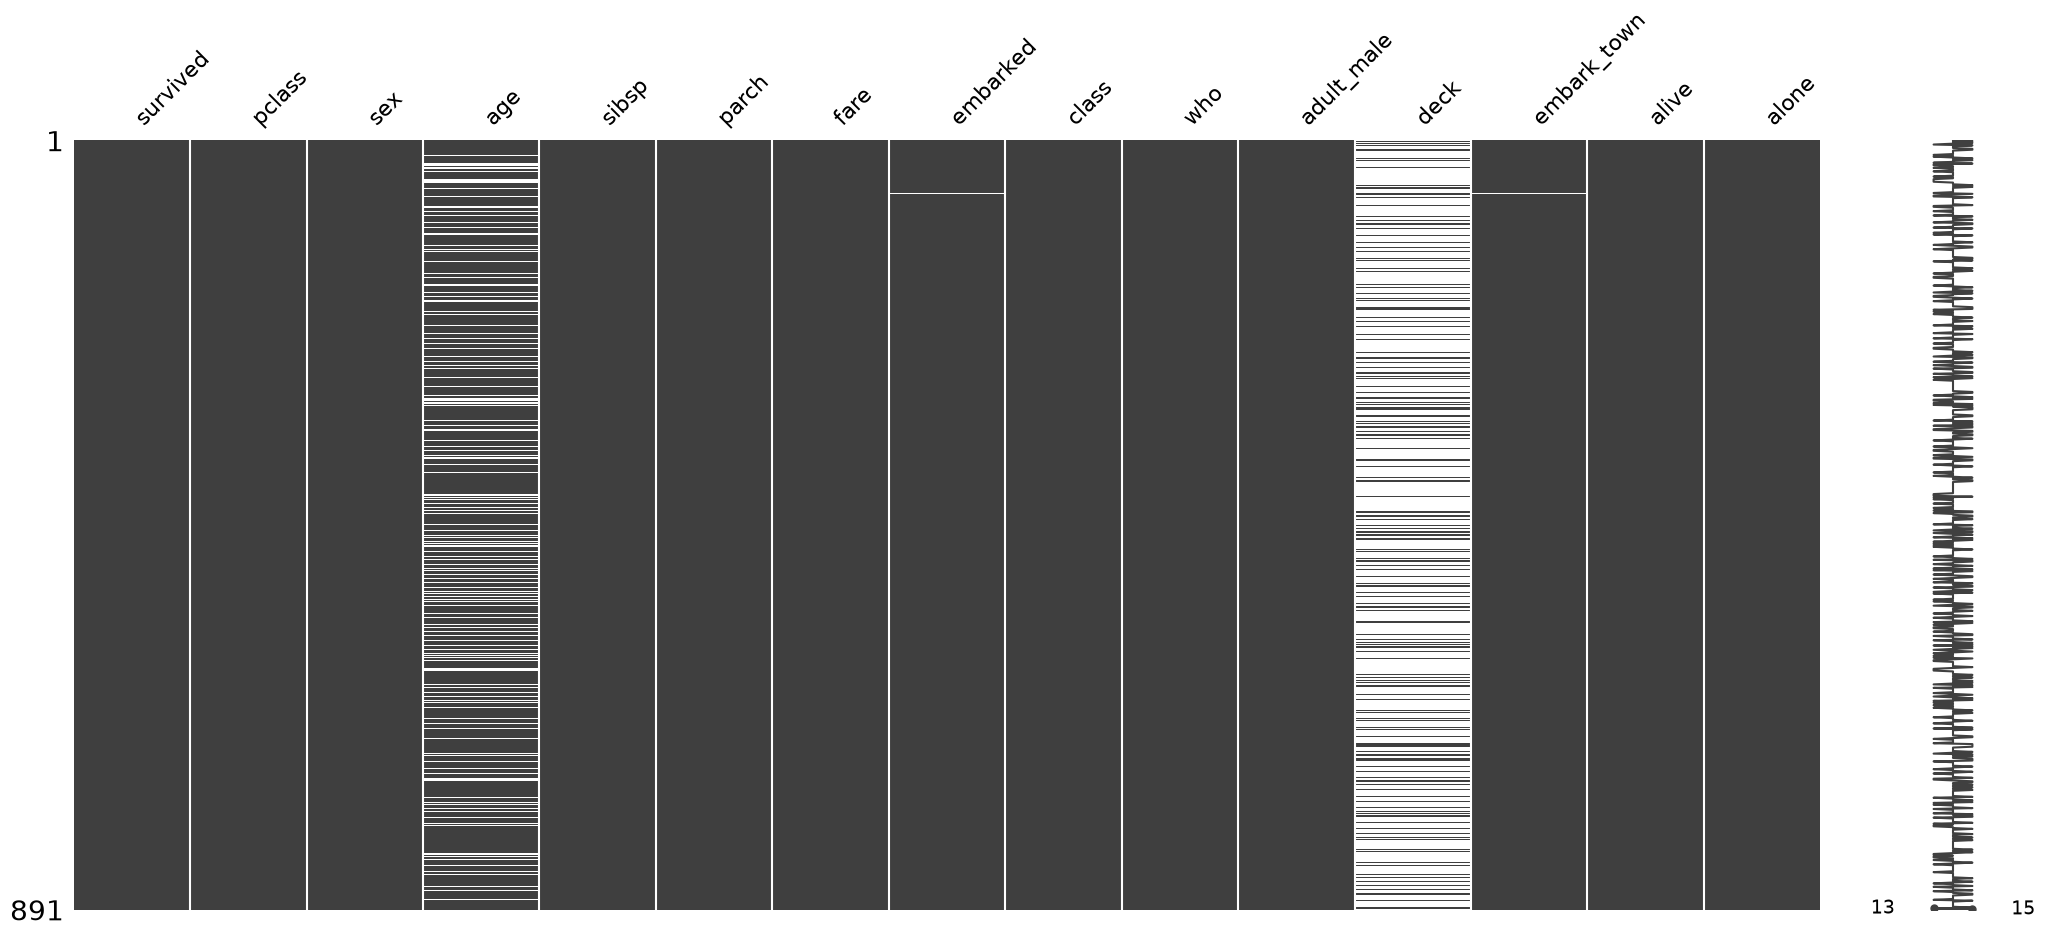

In [52]:
import missingno as msno
import matplotlib.pyplot as plt

msno.matrix(df)
plt.show()

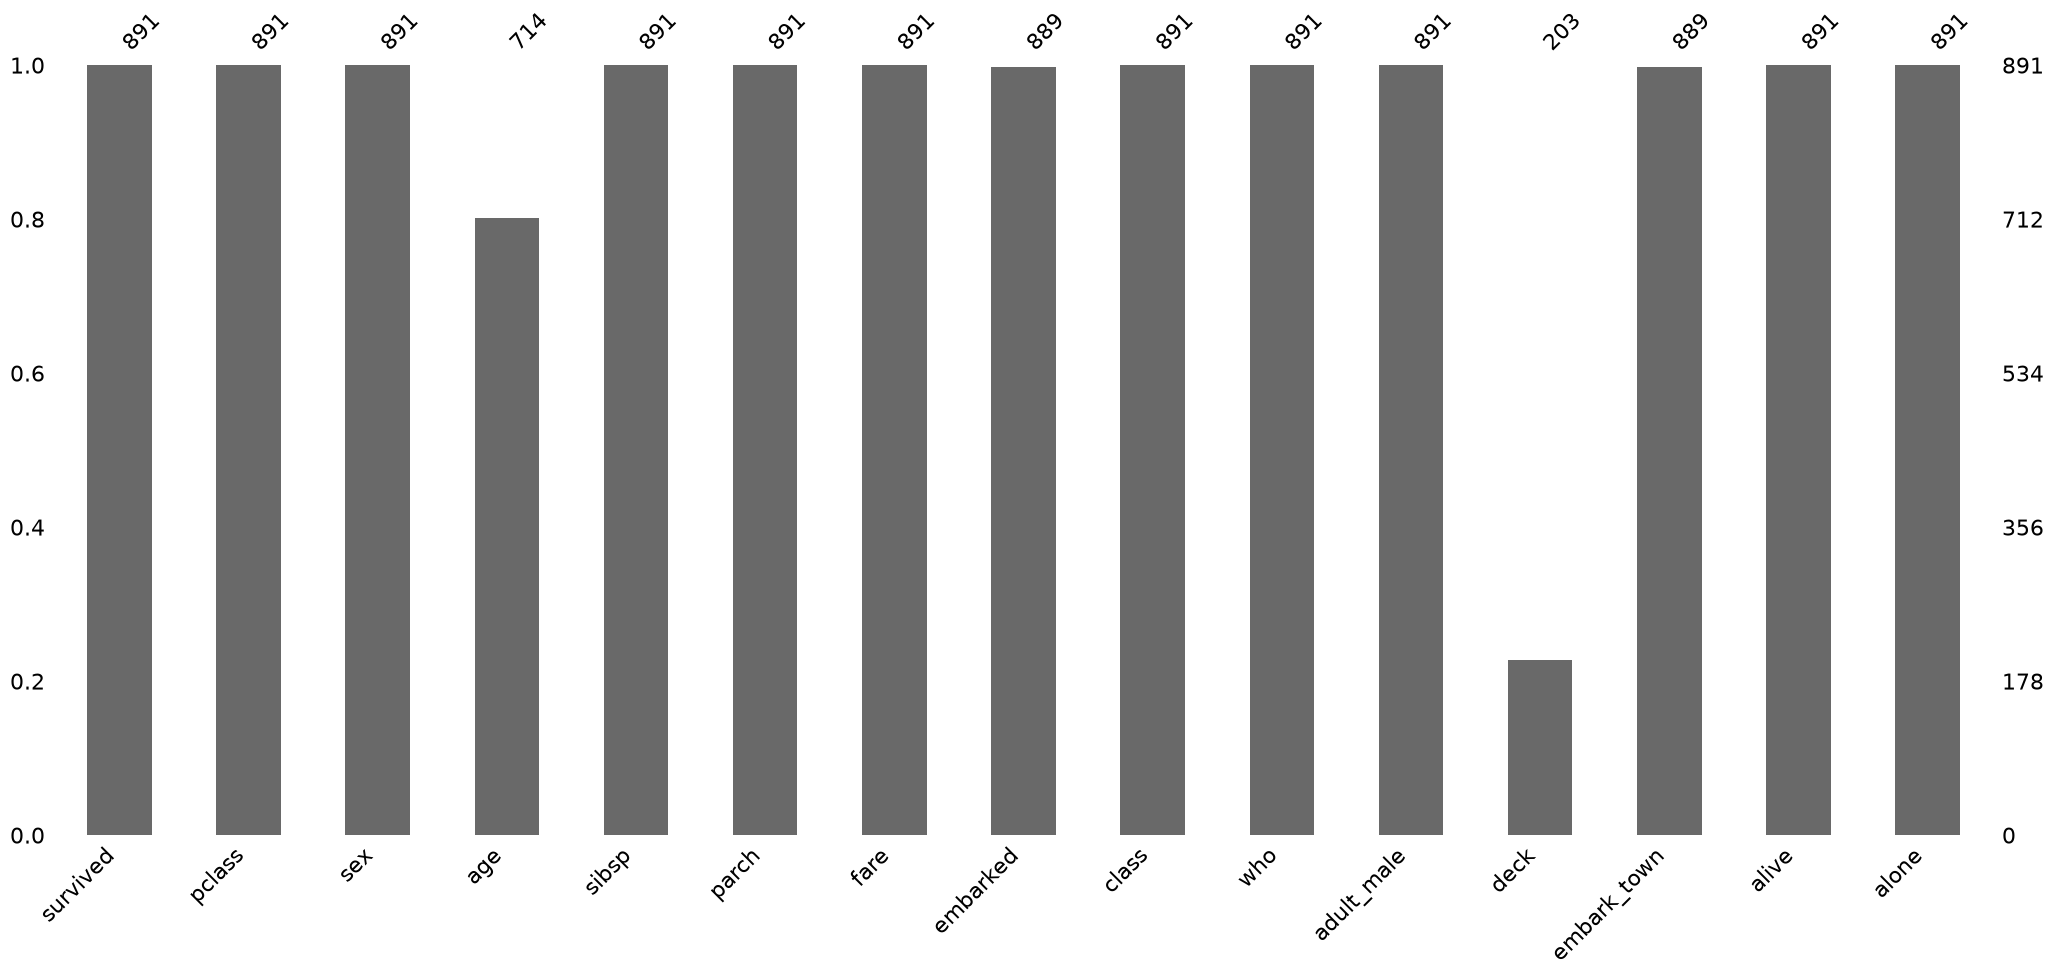

In [53]:
msno.bar(df)
plt.show()

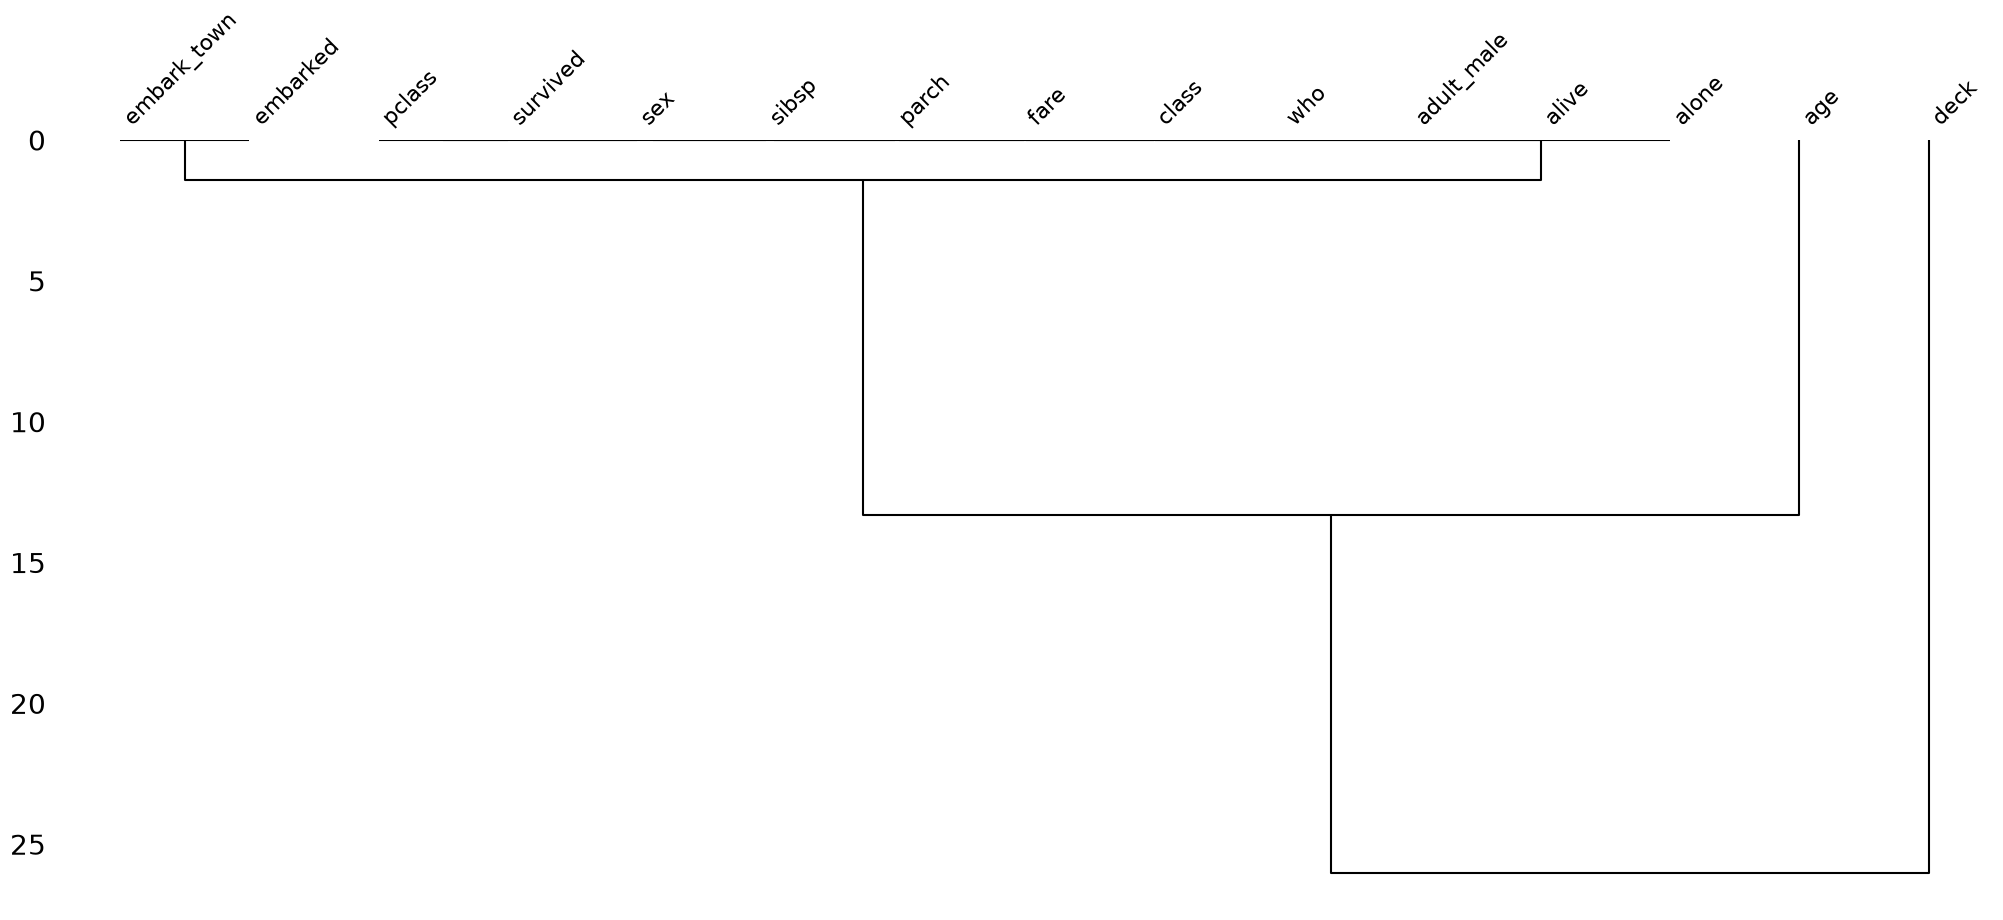

In [54]:
msno.dendrogram(df)
plt.show()

In [55]:
#누락데이터 표현

import pandas as pd

ser1 = pd.Series(
    [1,2,None]
)
ser1

0    1.0
1    2.0
2    NaN
dtype: float64

In [56]:
ser2 = pd.Series([1,2,None], dtype="Int64")
ser2

0       1
1       2
2    <NA>
dtype: Int64

In [57]:
#누락데이터 제거

import seaborn as sns

df = sns.load_dataset('titanic')

df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [58]:
df_thresh = df.dropna(axis=1, thresh=500)
print(df_thresh.columns)

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'embark_town', 'alive',
       'alone'],
      dtype='str')


In [59]:
df_age = df.dropna(subset=['age'], how='any', axis=0)
print(len(df_age))

714


In [60]:
df_age_deck = df.dropna(subset=['age','deck'], how='all', axis=0)
print(len(df_age_deck))

733


In [61]:
#누락데이터 대체

df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [62]:
df['age'].head(10)

0    22.0
1    38.0
2    26.0
3    35.0
4    35.0
5     NaN
6    54.0
7     2.0
8    27.0
9    14.0
Name: age, dtype: float64

In [63]:
mean_age = df['age'].mean()
df['age'] = df["age"].fillna(mean_age)
df['age'].head(10)

0    22.000000
1    38.000000
2    26.000000
3    35.000000
4    35.000000
5    29.699118
6    54.000000
7     2.000000
8    27.000000
9    14.000000
Name: age, dtype: float64

In [64]:
most_freq =df["embark_town"].value_counts(dropna=True).idxmax()

In [65]:
most_freq2 = df["embark_town"].mode()[0]

In [66]:
type(df["adult_male"].mode())

pandas.Series

In [67]:
df["embark_town"].describe()

count             889
unique              3
top       Southampton
freq              644
Name: embark_town, dtype: object

In [68]:
df["embark_town"].describe()["top"]

'Southampton'

In [69]:
df["embark_town"].fillna(most_freq)

0      Southampton
1        Cherbourg
2      Southampton
3      Southampton
4      Southampton
          ...     
886    Southampton
887    Southampton
888    Southampton
889      Cherbourg
890     Queenstown
Name: embark_town, Length: 891, dtype: str

In [70]:
df["embark_town"][825:830]

825     Queenstown
826    Southampton
827      Cherbourg
828     Queenstown
829            NaN
Name: embark_town, dtype: str

In [71]:
import seaborn as sns

df = sns.load_dataset('titanic')

df['embark_town'][825:830]

825     Queenstown
826    Southampton
827      Cherbourg
828     Queenstown
829            NaN
Name: embark_town, dtype: str

In [72]:

most_freq = df['embark_town'].value_counts(dropna=True).idxmax()   
print(most_freq)

most_freq2 = df['embark_town'].mode()[0]   
print(most_freq2)

Southampton
Southampton


In [73]:
df['embark_town'] = df['embark_town'].fillna(most_freq)

df['embark_town'][825:830]

825     Queenstown
826    Southampton
827      Cherbourg
828     Queenstown
829    Southampton
Name: embark_town, dtype: str

In [74]:
#이웃하고 있는 값으로 바꾸기
df = sns.load_dataset("titanic")
df2 = df.copy()

In [75]:
df["embark_town"][825:831]

825     Queenstown
826    Southampton
827      Cherbourg
828     Queenstown
829            NaN
830      Cherbourg
Name: embark_town, dtype: str

In [83]:
df2["embark_town"] = df["embark_town"].bfill()

In [84]:
df["embark_town"][825:831]

825     Queenstown
826    Southampton
827      Cherbourg
828     Queenstown
829      Cherbourg
830      Cherbourg
Name: embark_town, dtype: str